# Bank Titanic Dataset - Dataset Cleaning Project
## Oasis Infobyte - Data Analytics Internship

### **Full Name:** Bakithi Gabashane
### **Track:** Data Analytics
### **Task 3:** Cleaning Data

## Data Quality Report

### Before I can start cleaning the dataset, I need to understand what problems exist inside it. This report covers: null values, duplicate rows, data type issues, and value range anomalies.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
df.shape

(418, 12)

In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


## Null Value Analysis
### The dataset contains missing values in 3 columns:

- Age: 86 missing values (20.6%)
- Fare: 1 missing value (0.2%)
- Cabin: 327 missing values (78.2%)


In [6]:
df.duplicated().sum()

np.int64(0)

## Handling Duplicates

The dataset has 0 duplicates, therefore there is no need for removal.

In [7]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [8]:
print("-" * 50)
print("Data Type Issues:")
print("-" * 50)

for col in df.columns:
  print(f"{col}: {df[col].dtype} | sample values: {df[col].dropna().unique()[:5]}")

--------------------------------------------------
Data Type Issues:
--------------------------------------------------
PassengerId: int64 | sample values: [892 893 894 895 896]
Survived: int64 | sample values: [0 1]
Pclass: int64 | sample values: [3 2 1]
Name: object | sample values: ['Kelly, Mr. James' 'Wilkes, Mrs. James (Ellen Needs)'
 'Myles, Mr. Thomas Francis' 'Wirz, Mr. Albert'
 'Hirvonen, Mrs. Alexander (Helga E Lindqvist)']
Sex: object | sample values: ['male' 'female']
Age: float64 | sample values: [34.5 47.  62.  27.  22. ]
SibSp: int64 | sample values: [0 1 2 3 4]
Parch: int64 | sample values: [0 1 3 2 4]
Ticket: object | sample values: ['330911' '363272' '240276' '315154' '3101298']
Fare: float64 | sample values: [ 7.8292  7.      9.6875  8.6625 12.2875]
Cabin: object | sample values: ['B45' 'E31' 'B57 B59 B63 B66' 'B36' 'A21']
Embarked: object | sample values: ['Q' 'S' 'C']


In [9]:
print("-" * 50)
print("Value Range Anomalies - Numerical Columns")
print("-" * 50)

numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']

for col in numerical_cols:
  print(f"\n{col}:")
  print(f"Min: {df[col].min()}")
  print(f"Max: {df[col].max()}")
  print(f"Mean: {df[col].mean():.2f}")
  print(f"Negative values: {(df[col] < 0).sum()}")

--------------------------------------------------
Value Range Anomalies - Numerical Columns
--------------------------------------------------

Age:
Min: 0.17
Max: 76.0
Mean: 30.27
Negative values: 0

Fare:
Min: 0.0
Max: 512.3292
Mean: 35.63
Negative values: 0

SibSp:
Min: 0
Max: 8
Mean: 0.45
Negative values: 0

Parch:
Min: 0
Max: 9
Mean: 0.39
Negative values: 0

Pclass:
Min: 1
Max: 3
Mean: 2.27
Negative values: 0


In [10]:
print("-" * 50)
print("Value Range Anomalies - Catergorical Columns")
print("-" * 50)

catergorical_col = ['Sex', 'Embarked', 'Survived', 'Pclass']

for col in catergorical_col:
  print(f"\n{col} Unqiues Values: {df[col].unique()}")
  print(f"{col} Value counts:")
  print(df[col].value_counts().to_string())

--------------------------------------------------
Value Range Anomalies - Catergorical Columns
--------------------------------------------------

Sex Unqiues Values: ['male' 'female']
Sex Value counts:
Sex
male      266
female    152

Embarked Unqiues Values: ['Q' 'S' 'C']
Embarked Value counts:
Embarked
S    270
C    102
Q     46

Survived Unqiues Values: [0 1]
Survived Value counts:
Survived
0    266
1    152

Pclass Unqiues Values: [3 2 1]
Pclass Value counts:
Pclass
3    218
1    107
2     93


In [11]:
df_original = df.copy()

print("Original dataset saved for comparison")
print(f"Original shape: {df_original.shape}")

Original dataset saved for comparison
Original shape: (418, 12)


## Data Cleaning

I can now clean the dataset to address the issues identified in the quality report aboved.

In [12]:
print("Step 1: Drop Cabin Column")
print("-" * 50)
print(f"Columns before: {df.shape[1]}")

df = df.drop(columns=['Cabin'])

print(f"Columns after: {df.shape[1]}")
print("Cabin column dropped because 78.2% of values were missing")

Step 1: Drop Cabin Column
--------------------------------------------------
Columns before: 12
Columns after: 11
Cabin column dropped because 78.2% of values were missing


In [13]:
print("Step 2: Handle Missing Values")
print("-" * 50)

age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)
print(f"Age: filled {df_original['Age'].isnull().sum()} missing values with median ({age_median})")

fare_median = df['Fare'].median()
df['Fare'] = df['Fare'].fillna(fare_median)
print(f"Fare: filled {df_original['Fare'].isnull().sum()} missing value with median ({fare_median:.2f})")

print(f"\nNull values remaining: {df.isnull().sum().sum()}")

Step 2: Handle Missing Values
--------------------------------------------------
Age: filled 86 missing values with median (27.0)
Fare: filled 1 missing value with median (14.45)

Null values remaining: 0


## Imputing missing values with the median

I used the respective medians to impute each row's missing values in the 'Age' and 'Fare' columns. Values that are unusually high or low (out of IQR bounds) can affect the mean. The median gives a more reliable estimate of a typical passenger’s age and the fare they paid.



In [14]:
print("Step 3: Standardise Sex Column")
print("-" * 50)

print(f"Before: {df['Sex'].unique()}")
df['Sex'] = df['Sex'].str.capitalize()
print(f"After: {df['Sex'].unique()}")

Step 3: Standardise Sex Column
--------------------------------------------------
Before: ['male' 'female']
After: ['Male' 'Female']


In [15]:
print("Step 4: Fix Data Types")
print("-" * 50)

df['PassengerId'] = df['PassengerId'].astype(str)

df['Survived'] = df['Survived'].astype('category')

df['Pclass'] = df['Pclass'].astype('category')

print("Updated data types:")
print(df.dtypes)

Step 4: Fix Data Types
--------------------------------------------------
Updated data types:
PassengerId      object
Survived       category
Pclass         category
Name             object
Sex              object
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked         object
dtype: object


## Outlier Detection

### I will be using the IQR (Interquartile Range) to detect outliers in the numerical columns 'Age' and 'Fare'.

### IQR = Q3 - Q1
### Lower bound = Q1 - 1.5 * IQR
### Upper bound = Q1 + 1.5 * IQR

### Any value below the lower bound or above the upper bound is considered an outlier.

In [16]:
print("-" * 50)
print("Outlier Detection Using IQR Method")
print("-" * 50)

numerical_cols_for_iqr = [col for col in numerical_cols if df[col].dtype != 'category']

for col in numerical_cols_for_iqr:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

  print(f"\n{col}:")
  print(f" Q1: {Q1:.2f}")
  print(f" Q3: {Q3:.2f}")
  print(f" IQR: {IQR:.2f}")
  print(f" Lower bound: {lower_bound:.2f}")
  print(f" Upper bound: {upper_bound:.2f}")
  print(f" Number of Outliers: {len(outliers)}")
  print(f" Outlier Values: {sorted(outliers[col].values)[:5]} ...")

--------------------------------------------------
Outlier Detection Using IQR Method
--------------------------------------------------

Age:
 Q1: 23.00
 Q3: 35.75
 IQR: 12.75
 Lower bound: 3.88
 Upper bound: 54.88
 Number of Outliers: 36
 Outlier Values: [np.float64(0.17), np.float64(0.33), np.float64(0.75), np.float64(0.83), np.float64(0.92)] ...

Fare:
 Q1: 7.90
 Q3: 31.47
 IQR: 23.58
 Lower bound: -27.47
 Upper bound: 66.84
 Number of Outliers: 55
 Outlier Values: [np.float64(69.55), np.float64(69.55), np.float64(69.55), np.float64(69.55), np.float64(71.2833)] ...

SibSp:
 Q1: 0.00
 Q3: 1.00
 IQR: 1.00
 Lower bound: -1.50
 Upper bound: 2.50
 Number of Outliers: 11
 Outlier Values: [np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(4)] ...

Parch:
 Q1: 0.00
 Q3: 0.00
 IQR: 0.00
 Lower bound: 0.00
 Upper bound: 0.00
 Number of Outliers: 94
 Outlier Values: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)] ...


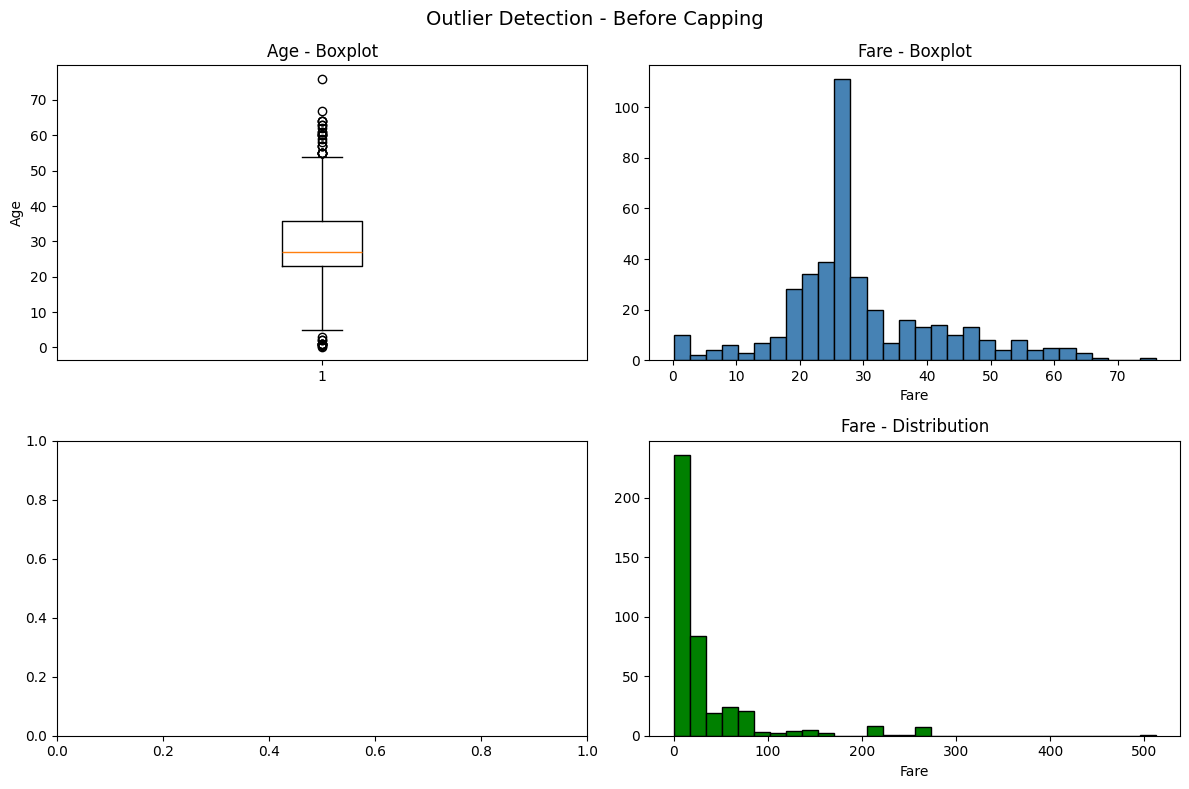

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Outlier Detection - Before Capping', fontsize=14)

axes[0, 0].boxplot(df['Age'].dropna())
axes[0, 0].set_title('Age - Boxplot')
axes[0, 0].set_ylabel('Age')

axes[0, 1].hist(df['Age'].dropna(), bins=30, color='steelblue', edgecolor='black')
axes[0, 1].set_title('Fare - Boxplot')
axes[0, 1].set_xlabel('Fare')

axes[1, 1].hist(df['Fare'].dropna(), bins=30, color='green', edgecolor='black')
axes[1, 1].set_title('Fare - Distribution')
axes[1, 1].set_xlabel('Fare')

plt.tight_layout()
plt.show()

In [18]:
print("Handling Outiers - Capping Method")
print("-" * 50)

numerical_cols_for_iqr = [col for col in numerical_cols if df[col].dtype != 'category']

for col in numerical_cols_for_iqr:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  before = len(df[(df[col] < lower_bound) | (df[col] > upper_bound)])

  df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

  after = len(df[(df[col] < lower_bound) | (df[col] > upper_bound)])

  print(f"\n{col}")
  print(f" Outliers before capping: {before}")
  print(f" Outliers after capping: {after}")
  print(f" Values capped to range: [{lower_bound:.2f}, {upper_bound:.2f}]")

Handling Outiers - Capping Method
--------------------------------------------------

Age
 Outliers before capping: 36
 Outliers after capping: 0
 Values capped to range: [3.88, 54.88]

Fare
 Outliers before capping: 55
 Outliers after capping: 0
 Values capped to range: [-27.47, 66.84]

SibSp
 Outliers before capping: 11
 Outliers after capping: 0
 Values capped to range: [-1.50, 2.50]

Parch
 Outliers before capping: 94
 Outliers after capping: 0
 Values capped to range: [0.00, 0.00]


## Capping vs Removing Outliers

For Age: outliers represent very young or very old passengers. These are real people and removing them would lose valid data. Capping preserves these rows while limiting extreme influence on analysis.

For Fare: extremely high fares (up to 512) are real first-class ticket prices. Removing these rows would bias the dataset toward lower classes. Capping brings them within a reasonable range without deleting the passenger record entirely.

## Before vs After Summary

This is a comparison of the dataset before and after the cleaning process.

In [19]:
print("-" * 100)
print("Before vs After Cleaning Summary")
print("-" * 100)

summary = pd.DataFrame({
    'Metric': [
        'Total Rows',
        'Total Columns',
        'Missing Values (Total)',
        'Duplicate Rows',
        'Age - Missing Values',
        'Fare - Missing Values',
        'Cabin - Missing Values',
        'Sex - Standardised',
        'PassengerId - Data Type',
        'Survived - Data Type',
        'Pclass - Data Type',
        'Age - Outliers',
        'Fare - Outliers',
    ],
    'Before Cleaning': [
        df_original.shape[0],
        df_original.shape[1],
        df_original.isnull().sum().sum(),
        df_original.duplicated().sum(),
        df_original['Age'].isnull().sum(),
        df_original['Fare'].isnull().sum(),
        df_original['Cabin'].isnull().sum(),
        'lowercase (male/female)',
        str(df_original['PassengerId'].dtype),
        str(df_original['Survived'].dtype),
        str(df_original['Pclass'].dtype),
        'Not yet checked',
        'Not yet checked'
    ],
    'After Cleaning': [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        df['Age'].isnull().sum(),
        df['Fare'].isnull().sum(),
        'Column dropped',
        'Capitalised (Male/Female)',
        str(df['PassengerId'].dtype),
        str(df['Survived'].dtype),
        str(df['Pclass'].dtype),
        'Capped using IQR',
        'Capped using IQR'
    ],
    'Action Taken': [
        'No change',
        'Dropped Cabin column',
        'Resolved',
        'None found',
        'Imputed with median',
        'Imputed with median',
        'Dropped - 78.2% missing',
        'str.capitalized() applied',
        'Changed to string',
        'Changed to category',
        'Changed to category',
        'Capped at IQR bounds',
        'Capped at IQR bounds'
    ]
})

print(summary.to_string(index=False))

----------------------------------------------------------------------------------------------------
Before vs After Cleaning Summary
----------------------------------------------------------------------------------------------------
                 Metric         Before Cleaning            After Cleaning              Action Taken
             Total Rows                     418                       418                 No change
          Total Columns                      12                        11      Dropped Cabin column
 Missing Values (Total)                     414                         0                  Resolved
         Duplicate Rows                       0                         0                None found
   Age - Missing Values                      86                         0       Imputed with median
  Fare - Missing Values                       1                         0       Imputed with median
 Cabin - Missing Values                     327            Column

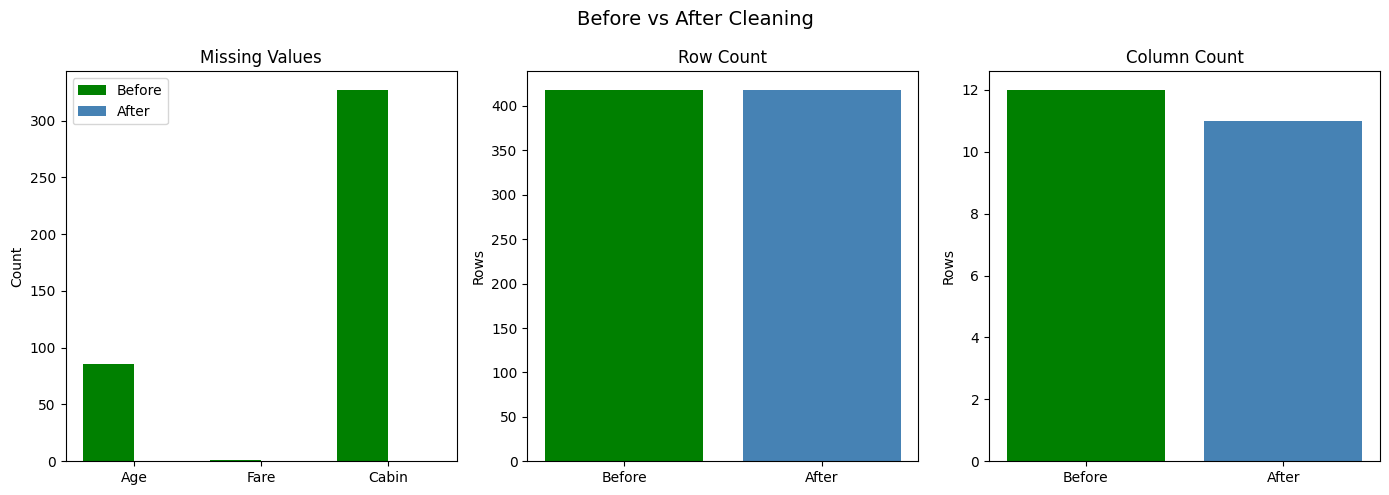

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Before vs After Cleaning', fontsize=14)

categories = ['Age', 'Fare', 'Cabin']
before_nulls = [
    df_original['Age'].isnull().sum(),
    df_original['Fare'].isnull().sum(),
    df_original['Cabin'].isnull().sum(),
]
after_nulls = [
    df['Age'].isnull().sum(),
    df['Fare'].isnull().sum(),
    0
]

x = range(len(categories))
axes[0].bar([i - 0.2 for i in x], before_nulls, 0.4, label='Before', color='green')
axes[0].bar([i + 0.2 for i in x], after_nulls, 0.4, label='After', color='steelblue')
axes[0].set_title('Missing Values')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(categories)
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].bar(['Before',  'After'], [df_original.shape[0], df.shape[0]], color=['green', 'steelblue'])
axes[1].set_title('Row Count')
axes[1].set_ylabel('Rows')

axes[2].bar(['Before', 'After'], [df_original.shape[1], df.shape[1]], color=['green', 'steelblue'])
axes[2].set_title('Column Count')
axes[2].set_ylabel('Rows')

plt.tight_layout()
plt.show()

In [21]:
print("-" * 50)
print("Saving Cleaned Dataset")
print("-" * 50)

df.to_csv('titanic_cleaned', index=False)

print("Cleaned dataset saved as: titanic_cleaned.csv" )
print(f"Final shape: {df.shape}")
print(f"Final columns: {list(df.columns)}")
print(f"Total null values remaining: {df.isnull().sum().sum()}")

--------------------------------------------------
Saving Cleaned Dataset
--------------------------------------------------
Cleaned dataset saved as: titanic_cleaned.csv
Final shape: (418, 11)
Final columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']
Total null values remaining: 0


## Conclusion

I have successfully cleaned the titanic dataset and now it is ready for analysis. The following changes were made:

1. Dropped the Cabin column because it had 78.2% missing values.
2. Imputed 86 missing 'Age' values with the median age 27.0.
3. Imputed 1 missing 'Fare' value with the median fare 14.45.
4. Standardised 'Sex' column from lowercase to capitalised.
5. Corrected data types for 'PassengerId', 'Survived' and 'Pclass' columns.
6. Detected and capped outliers in the 'Age' and 'Fare' columns using IQR method.

The cleaned dataset contains 418 rows and 11 columns with zero missing values, ready for analysis or machine learning.